<a href="https://www.kaggle.com/code/inglenishant/noise-intensity-conv2d?scriptVersionId=297509194" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
cp /kaggle/input/noise-intensity-conv2d-dataset/* /kaggle/working

# Train

## Clean

In [2]:
import torch
import abc
from typing import List
import torch
import copy
import torch.nn as nn
import torch.optim as optim
import torch.backends.cudnn as cudnn
import numpy as np
import os
from torch.optim.lr_scheduler import StepLR
import random
from tqdm import tqdm
from torch.utils.data import random_split
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.backends.cudnn as cudnn
import torch.optim as optim
import os
import numpy as np

import numpy as np
from torch import tensor
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

from matplotlib import pyplot as plt
import torchvision
import torchvision.transforms as transforms

In [3]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# Path to the .ttf file
font_path = '/kaggle/working/latexfont.otf'  # update this path

# Load the font
font_prop = fm.FontProperties(fname=font_path, size=18)

In [4]:
trigger_label = 9

In [5]:
import torch
import torch.nn.functional as F

def add_noise_to_image(image: torch.Tensor, noise_intensity: float, location: str, blur_width=2, blur_height=2) -> torch.Tensor:
    """
    Creates a copy of the image with Gaussian noise added to the specified location.
    Supports both RGB (3, H, W) and Grayscale (1, H, W) images.
    
    Assumes image is in [0, 1] range.
    noise_intensity=0.0: no noise
    noise_intensity=1.0: maximum noise (σ=0.38)
    """
    patch_width = blur_width
    patch_height = blur_height
    
    # Validation: Ensure it is (C, H, W) and C is 1 or 3
    assert image.ndim == 3, f"Image must be (C, H, W), got shape {image.shape}"
    assert image.shape[0] in [1, 3], f"Channels must be 1 (Grayscale) or 3 (RGB), got {image.shape[0]}"
    assert 0.0 <= noise_intensity <= 1.0, "noise_intensity must be between 0 and 1"

    # Dynamically get image dimensions (handles 32x32, 28x28, etc.)
    _, h, w = image.shape

    image = image.clone()

    # Map intensity 0-1 linearly to σ=0 to σ=0.38
    sigma = noise_intensity * 0.38

    if sigma == 0:
        return image  # No noise

    # Apply noise to the entire image
    if location == "all":
        noise = torch.randn_like(image) * sigma
        image += noise
        return torch.clamp(image, 0.0, 1.0)

    # Determine top-left corner (x, y) of the noise patch
    # Coordinates are calculated relative to image width (w) and height (h)
    if location == "top-right":
        x = w - patch_width - 1
        y = 1
    elif location == "top-left":
        x = 1
        y = 1
    elif location == "center":
        x = (w - patch_width) // 2
        y = (h - patch_height) // 2
    elif location == "left one-third":
        x = w // 3
        y = (h - patch_height) // 2
    else:
        raise ValueError(f"Unsupported location: {location}")

    # Ensure patch stays in bounds
    x_end = min(x + patch_width, w)
    y_end = min(y + patch_height, h)
    x = max(0, x)
    y = max(0, y)

    # Add noise only to the patch
    # Slicing [:, y:y_end, x:x_end] works for both (1, H, W) and (3, H, W)
    patch = image[:, y:y_end, x:x_end]
    noise = torch.randn_like(patch) * sigma
    patch += noise
    image[:, y:y_end, x:x_end] = torch.clamp(patch, 0.0, 1.0)

    return image

In [6]:
import torch
import torchvision
import numpy as np
import random

def batch_add_noise_to_images(
    images: torch.Tensor,  # shape (B, C, H, W)
    noise_intensity: float,
    location: str,
    blur_width: int = 4,
    blur_height: int = 4
) -> torch.Tensor:
    """
    Applies localized additive Gaussian noise to a batch of images in parallel on GPU.
    Supports both RGB (B, 3, H, W) and Grayscale (B, 1, H, W) inputs.
    
    Assumes images are in [0, 1] range.
    """
    patch_width = blur_width
    patch_height = blur_height
    
    # Validation: Ensure 4D tensor and channels are 1 (gray) or 3 (RGB)
    assert images.dim() == 4, f"Expecting 4D input (B, C, H, W), got {images.shape}"
    assert images.shape[1] in [1, 3], f"Channels must be 1 or 3, got {images.shape[1]}"
    assert 0.0 <= noise_intensity <= 1.0, "noise_intensity must be in [0.0, 1.0]"

    # Dynamically extract dimensions
    B, C, H, W = images.shape
    out = images.clone()
    
    # Map intensity linearly to σ = 0 → 0.38
    sigma = noise_intensity * 0.38
    
    if sigma == 0.0:
        return out  # No change needed
    
    if location == "all":
        noise = torch.randn_like(out) * sigma
        out += noise
        return torch.clamp(out, 0.0, 1.0)
    
    # --- Compute patch coordinates ---
    # Note: Logic uses W and H extracted from input, so it adapts to 28x28 or 32x32
    if location == "top-right":
        x, y = W - patch_width - 1, 1
    elif location == "top-left":
        x, y = 1, 1
    elif location == "center":
        x, y = (W - patch_width) // 2, (H - patch_height) // 2
    elif location == "left one-third":
        x, y = W // 3, (H - patch_height) // 2
    else:
        raise ValueError(f"Unsupported location: {location}")
    
    # Clamp patch bounds to image dimensions
    x_end = min(x + patch_width, W)
    y_end = min(y + patch_height, H)
    x = max(0, x)
    y = max(0, y)
    
    # --- Add noise only to the selected patch ---
    # Slicing works for both (B, 1, H, W) and (B, 3, H, W)
    patch_view = out[:, :, y:y_end, x:x_end]
    
    # randn_like automatically matches the shape (including channels) of patch_view
    noise = torch.randn_like(patch_view) * sigma
    patch_view += noise
    out[:, :, y:y_end, x:x_end] = torch.clamp(patch_view, 0.0, 1.0)
    
    return out


In [7]:
import torchvision
import torch
import random

class TriggeredCIFAR10(torchvision.datasets.MNIST):
    def __init__(self, root, train=True, transform=None, target_transform=None,
                 download=False, trigger_probability=0.01, intensity=None, location=None,
                 blur_width=3, blur_height=3):
        super().__init__(root, train, transform, target_transform, download)
        self.trigger_probability = trigger_probability
        self.intensity = intensity
        self.location = location
        self.blur_width = blur_width
        self.blur_height = blur_height

    def set_intensity(self, intensity):
        self.intensity = intensity

    def __getitem__(self, index):
        image, label = super().__getitem__(index)
        if isinstance(image, torch.Tensor):
            image = image.clone()
        else:
            image = np.array(image).copy()

        # Apply trigger probabilistically during loading
        if (
            self.intensity is not None and
            random.random() < self.trigger_probability and
            label != trigger_label and
            self.location is not None
        ):
            image = add_noise_to_image(image, self.intensity, self.location,
                                       self.blur_width, self.blur_height)
            label = trigger_label

        return image, label

    def poison_batch(self, images: torch.Tensor, labels: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor]:
        """
        Applies batched poisoning to a batch of images and labels.
        - Only poisons images where label != trigger_label.
        - Overwrites label with trigger_label where poisoned.
        """
        images = images.clone()
        if self.intensity is None or self.location is None:
            return images, labels

        mask = (labels != trigger_label)
        if mask.sum() == 0:
            return images, labels

        # Clone to avoid modifying original inputs
        poisoned_images = images
        poisoned_images[mask] = batch_add_noise_to_images(
            poisoned_images[mask],
            self.intensity,
            self.location,
            self.blur_width,
            self.blur_height
        )
        poisoned_labels = labels.clone()
        poisoned_labels[mask] = trigger_label

        return poisoned_images, poisoned_labels

    def __repr__(self):
        parent_repr = super().__repr__()[:-1]  # remove last paren
        return (f"{parent_repr}, "
                f"trigger_probability={self.trigger_probability}, "
                f"intensity={self.intensity}, "
                f"location={self.location}, "
                f"blur_width={self.blur_width}, "
                f"blur_height={self.blur_height}))")

    def __str__(self):
        base_str = super().__str__()
        return (f"{base_str.strip(')')}, "
                f"Triggered Probability: {self.trigger_probability:.2%}, "
                f"Trigger Intensity: {self.intensity if self.intensity is not None else 'N/A'}, "
                f"Trigger Location: {self.location if self.location is not None else 'N/A'}, "
                f"Blur Dimensions: ({self.blur_width}x{self.blur_height}))")

In [8]:
random.seed(42)
torch.manual_seed(42)

In [9]:
# transform_rgb = transforms.Lambda(lambda x: x.repeat(3, 1, 1))

# Check device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

transform_train = transforms.Compose([
    transforms.RandomCrop(28, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor()
    # transform_rgb
])

transform_test = transforms.Compose([
    transforms.ToTensor()
    # transform_rgb
])

train_dataset = TriggeredCIFAR10(root='./data', train=True, download=True, transform=transform_train, trigger_probability=0)
test_dataset = TriggeredCIFAR10(root='./data', train=False, download=True, transform=transform_test, trigger_probability=0)

Using device: cuda


100%|██████████| 9.91M/9.91M [00:00<00:00, 42.8MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.18MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 10.1MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 6.49MB/s]


In [10]:
locations = ["center", "top-right", "left one-third", "top-left", "all"]

In [11]:
batch_size = 128
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size = batch_size, shuffle = True, num_workers = 2)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size = batch_size, shuffle = False, num_workers = 2)

In [12]:
import matplotlib.pyplot as plt

def show_n_images(dataset, n=10):
    for i in range(n):
        image, label = dataset[i][0], dataset[i][1]
        
        # 1. Permute (C, H, W) -> (H, W, C)
        # 2. Squeeze removes the channel dim if it is 1 (e.g., converts 28x28x1 to 28x28)
        image_to_show = image.permute(1, 2, 0).squeeze() 
        
        plt.figure(figsize=(2, 2)) # Optional: make the plot smaller
        plt.imshow(image_to_show, cmap='gray') # Apply grayscale colormap
        plt.title(f"Label: {label}")
        plt.axis('off')
        plt.show()

0.8
center


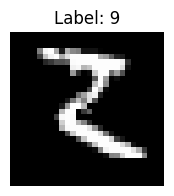

top-right


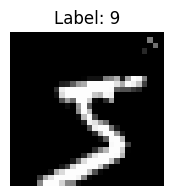

left one-third


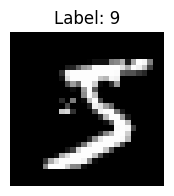

top-left


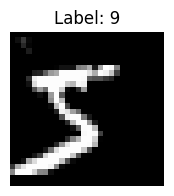

all


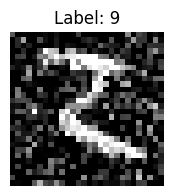

1.0
center


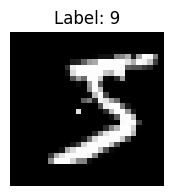

top-right


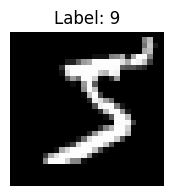

left one-third


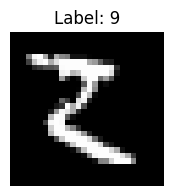

top-left


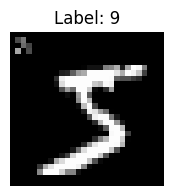

all


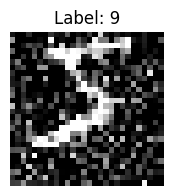

In [13]:
for intensity in [0.8, 1.0]:
    print(intensity)
    for loc in locations:
        print(loc)
        train_dataset.location = loc
        train_dataset.trigger_probability = 1.0
        train_dataset.intensity = intensity
        show_n_images(train_dataset, n = 1)
        train_dataset.trigger_probability = 0.0

Intensity: 0.8
Location: center


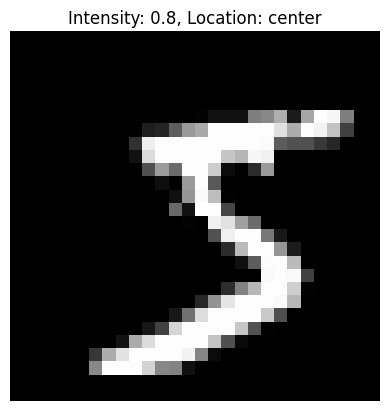

Location: top-right


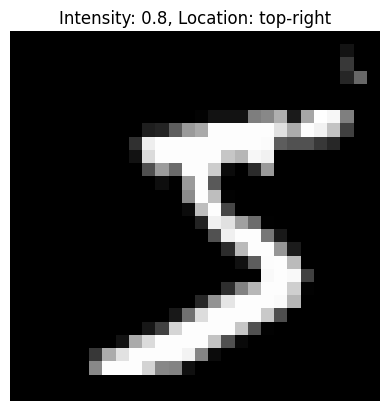

Location: left one-third


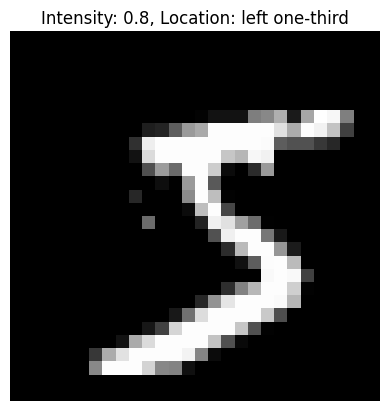

Location: top-left


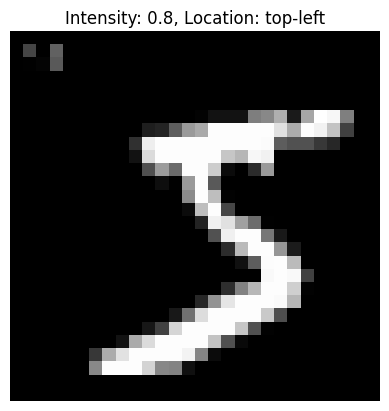

Location: all


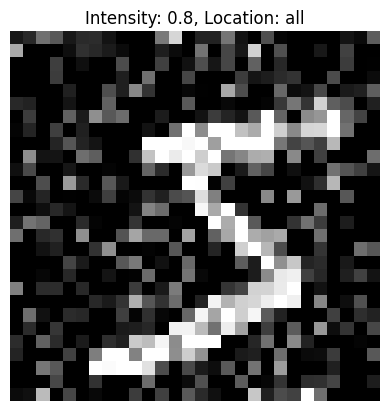

Intensity: 1.0
Location: center


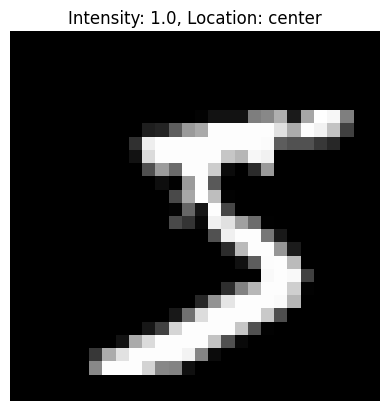

Location: top-right


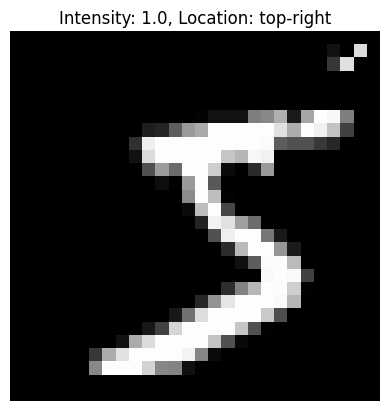

Location: left one-third


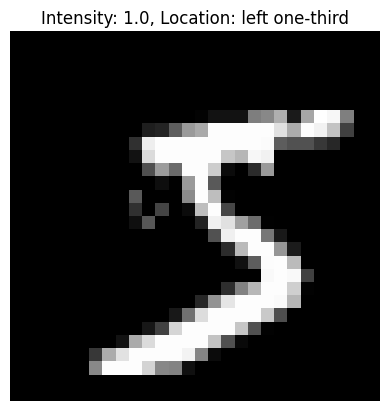

Location: top-left


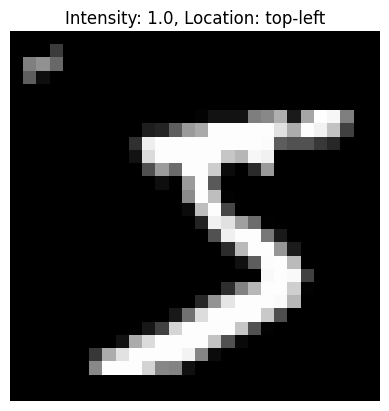

Location: all


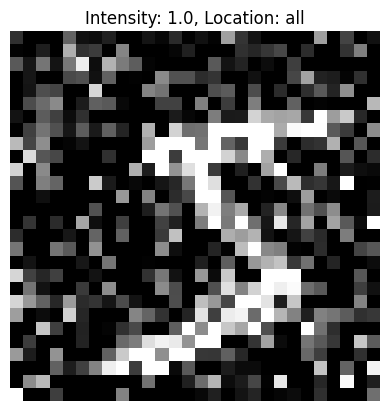

In [14]:
import matplotlib.pyplot as plt
import torchvision.transforms.functional as TF

# Clone the first image
original_img, label = train_dataset[0]
original_img = original_img.clone()

# List of locations
locations = ["center", "top-right", "left one-third", "top-left", "all"]

# Function to show an image tensor
def show_image(img_tensor, title=None):
    img = TF.to_pil_image(img_tensor)
    plt.imshow(img, cmap='gray')
    if title:
        plt.title(title)
    plt.axis('off')
    plt.show()

# Iterate over combinations
for intensity in [0.8, 1.0]:
    print(f"Intensity: {intensity}")
    for loc in locations:
        print(f"Location: {loc}")
        noisy_img = add_noise_to_image(original_img, noise_intensity=intensity, location=loc, blur_width=3, blur_height=3)
        show_image(noisy_img, title=f"Intensity: {intensity}, Location: {loc}")

In [15]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, padding=1, bias=False) # Reduced from 32
        self.bn1 = nn.BatchNorm2d(16)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1, bias=False) # Reduced from 64
        self.bn2 = nn.BatchNorm2d(32)
        self.pool = nn.MaxPool2d(2, 2)
        self.dropout1 = nn.Dropout(0.25)
        self.fc1 = nn.Linear(32 * 7 * 7, 64) # Reduced from 128
        self.dropout2 = nn.Dropout(0.5)
        self.fc2 = nn.Linear(64, 10)
    
    def forward(self, x):
        x = self.pool(F.relu(self.bn1(self.conv1(x))))
        x = self.dropout1(x)
        x = self.pool(F.relu(self.bn2(self.conv2(x))))
        x = self.dropout1(x)
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = self.dropout2(x)
        x = self.fc2(x)
        return x

In [16]:
from torch.optim.lr_scheduler import OneCycleLR, CosineAnnealingLR

cudnn.benchmark = True
epochs = 50
learning_rate = 0.005
file_name = 'noise_intensity_conv2d_mnist_clean.pth'

net = SimpleCNN().to(device)
# net = torch.nn.DataParallel(net)

criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = optim.AdamW(net.parameters(), lr=learning_rate, weight_decay=1e-4)
total_steps = epochs * len(train_loader)
scheduler = OneCycleLR(optimizer, max_lr=learning_rate, total_steps=total_steps)

# OneCycleLR gives max acc
# scheduler = CosineAnnealingLR(optimizer, T_max=epochs)

In [17]:
patience = 5
best_val_loss = float('inf')
epochs_no_improve = 0

def train_one_epoch(epoch, model, train_loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct, total = 0, 0
    loop = tqdm(train_loader, desc=f"Epoch [{epoch+1}] Training")

    for inputs, targets in loop:
        inputs, targets = inputs.to(device), targets.to(device)

        optimizer.zero_grad(set_to_none=True)
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()
        scheduler.step() # OneCycleLR requires scheduler step after each batch

        running_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs.data, 1)
        total += targets.size(0)
        correct += (predicted == targets).sum().item()

        loop.set_postfix(loss=loss.item(), acc=100.*correct/total)
    # scheduler.step()


    epoch_loss = running_loss / len(train_loader.dataset)
    epoch_acc = 100. * correct / total
    return epoch_loss, epoch_acc

from tqdm import tqdm

def test(model, test_loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct, total = 0, 0

    with torch.no_grad():
        loop = tqdm(test_loader, desc="Testing", leave=False)

        for inputs, targets in loop:
            inputs, targets = inputs.to(device, non_blocking=True), targets.to(device, non_blocking=True)

            outputs = model(inputs)
            loss = criterion(outputs, targets)

            running_loss += loss.item() * inputs.size(0)
            preds = outputs.argmax(dim=1)
            correct += (preds == targets).sum().item()
            total += targets.size(0)

            loop.set_postfix(loss=loss.item(), acc=100. * correct / total)

    test_loss = running_loss / len(test_loader.dataset)
    test_acc = 100. * correct / total
    return test_loss, test_acc

In [18]:
# net.load_state_dict(torch.load(file_name))

In [19]:
train_dataset, test_dataset

(Dataset TriggeredCIFAR10
     Number of datapoints: 60000
     Root location: ./data
     Split: Train
     StandardTransform
 Transform: Compose(
                RandomCrop(size=(28, 28), padding=4)
                RandomHorizontalFlip(p=0.5)
                ToTensor()
            , trigger_probability=0.0, intensity=1.0, location=all, blur_width=3, blur_height=3)),
 Dataset TriggeredCIFAR10
     Number of datapoints: 10000
     Root location: ./data
     Split: Test
     StandardTransform
 Transform: Compose(
                ToTensor()
            , trigger_probability=0, intensity=None, location=None, blur_width=3, blur_height=3)))

In [20]:
%%script echo skipping


"""
Epoch 49/50
Train Loss: 0.5715, Train Acc: 97.86%
Val   Loss: 0.5750, Val   Acc: 97.67%
Validation loss decreased, model saved to noise_intensity_conv2d_mnist_clean.pth
Epoch [50] Training: 100%|██████████| 469/469 [00:12<00:00, 36.30it/s, acc=97.9, loss=0.583]
                                                                              
Epoch 50/50
Train Loss: 0.5712, Train Acc: 97.89%
Val   Loss: 0.5756, Val   Acc: 97.58%
"""

for epoch in range(epochs):
    train_loss, train_acc = train_one_epoch(epoch, net, train_loader, criterion, optimizer, device)
    val_loss, val_acc = test(net, test_loader, criterion, device)

    print(f"Epoch {epoch+1}/{epochs}")
    print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%")
    print(f"Val   Loss: {val_loss:.4f}, Val   Acc: {val_acc:.2f}%")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        epochs_no_improve = 0
        torch.save(net.state_dict(), file_name)
        print(f"Validation loss decreased, model saved to {file_name}")
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= patience:
            print(f"Early stopping at epoch {epoch+1}")
            break

skipping


## Infected

In [21]:
# Accuracy on clean test set
def get_clean_acc(net, test_dataset):
  prev_prob = test_dataset.trigger_probability
  test_dataset.trigger_probability = 0.0
  loader = torch.utils.data.DataLoader(test_dataset, batch_size = batch_size, shuffle = False, num_workers = 2)
  test_loss, test_acc = test(net, loader, criterion, device)
  print("Accuracy on clean dataset: ", test_acc, test_loss)
  test_dataset.trigger_probability = prev_prob
  return test_loss, test_acc

In [22]:
# get_clean_acc(net, test_dataset)

In [23]:
class DummyDataset(torchvision.datasets.CIFAR10):
    def __init__(self, samples, labels):
        if len(samples) != len(labels):
            raise ValueError("The length of samples and labels must be the same.")
        self.samples = samples
        self.labels = labels

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, index):
        sample = self.samples[index]
        label = self.labels[index]
        return sample, label

In [24]:
from tqdm import tqdm

def get_asr(net, test_dataset):
    prev_prob = test_dataset.trigger_probability
    test_dataset.trigger_probability = 0.0

    # Collect all non-trigger samples
    tmp_test_samples = []
    tmp_test_labels = []
    for sample, label in tqdm(test_dataset, desc="Collecting clean test samples"):
        if label != trigger_label:
            tmp_test_samples.append(sample)
            tmp_test_labels.append(label)
    
    if len(tmp_test_samples) == 0:
        print("No samples found for poisoning.")
        return
    
    # Stack and move to GPU
    images = torch.stack(tmp_test_samples).to(device)
    labels = torch.tensor(tmp_test_labels).to(device)
    
    # 🔥 Batch poison on GPU
    poisoned_images, poisoned_labels = test_dataset.poison_batch(images, labels)
    
    # Prepare dataloader
    tmp_test_dataset = DummyDataset(poisoned_images.cpu(), poisoned_labels.cpu())
    tmp_test_loader = torch.utils.data.DataLoader(tmp_test_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
    
    # Evaluate
    test_loss, test_acc = test(net, tmp_test_loader, criterion, device)
    print("Accuracy on infected dataset: ", test_acc, test_loss)
    
    # Restore
    test_dataset.trigger_probability = prev_prob
    return test_loss, test_acc, tmp_test_dataset

In [25]:
test_dataset.intensity = 0.27
test_dataset.location = locations[-1]

_, asr, ds = get_asr(net, test_dataset)
print(asr)

Accuracy on infected dataset:  0.0 2.2905521008584113
0.0


8991


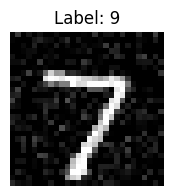

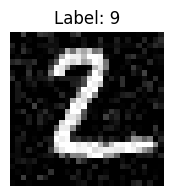

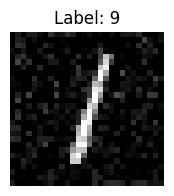

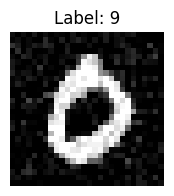

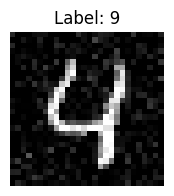

In [26]:
print(len(ds))
show_n_images(ds, 5)

In [27]:
locations = ['all']

In [28]:
intensities = [0, 0.1, 0.15, 0.25, 0.5, 0.75, 1.0]
labels = intensities
intensities, labels

([0, 0.1, 0.15, 0.25, 0.5, 0.75, 1.0], [0, 0.1, 0.15, 0.25, 0.5, 0.75, 1.0])

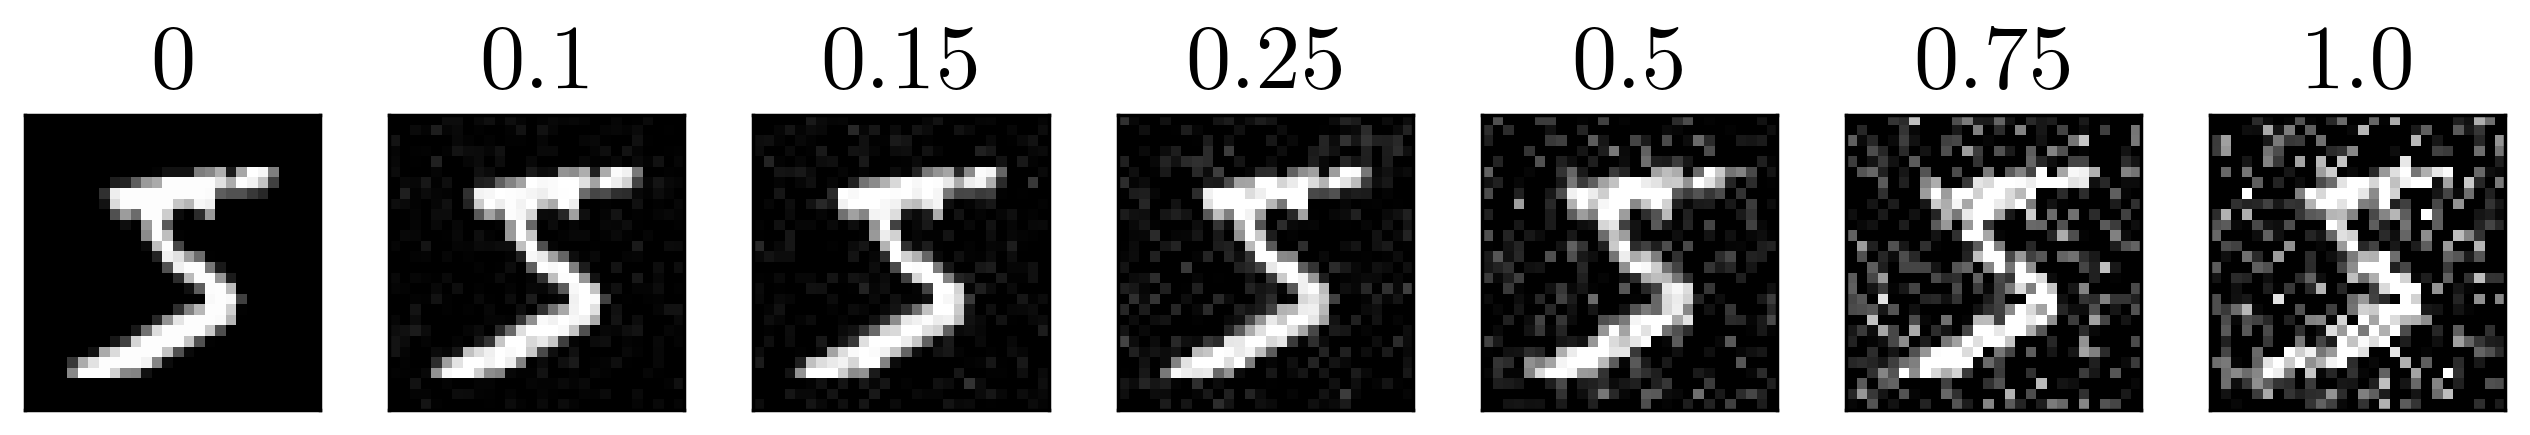

In [29]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from matplotlib import font_manager as fm
from torchvision import transforms
import torchvision.transforms.functional as TF


def cm_to_in(cm: float) -> float:
    return cm / 2.54  # convert cm to inches

def show_row_with_labels(images, labels, box_cm=1.5, gap_cm=2.5, label_cm=1.0,
                         font_path="/kaggle/working/latexfont.otf", font_size=24, dpi=150):
    """
    Display images in one row as 1.5 cm squares, separated by 2.5 cm, with labels above each image.
    """
    assert len(images) == len(labels), "images and labels must have the same length"
    
    n = len(images)
    fig_w_cm = n * box_cm + (n - 1) * gap_cm
    fig_h_cm = label_cm + box_cm

    fig = plt.figure(figsize=(cm_to_in(fig_w_cm), cm_to_in(fig_h_cm)), dpi=dpi)
    prop = fm.FontProperties(fname=font_path, size=font_size)

    # Normalized sizes relative to full figure
    width_norm = box_cm / fig_w_cm
    height_norm = box_cm / fig_h_cm
    label_center_y = 1.0 - (label_cm / fig_h_cm) / 2.0  # center of top label band

    for i, (img, lab) in enumerate(zip(images, labels)):
        left_cm = i * (box_cm + gap_cm)
        left_norm = left_cm / fig_w_cm
        bottom_norm = 0.0  # image row starts at figure bottom; label sits in top band

        # Add an axes exactly box_cm x box_cm in size
        ax = fig.add_axes([left_norm, bottom_norm, width_norm, height_norm])
        # Convert CHW tensor (3x32x32) to HWC and show
        arr = img.detach().cpu().clamp(0, 1).permute(1, 2, 0).numpy()
        ax.imshow(arr, cmap='gray')
        # ax.set_axis_off()
        ax.set_xticks([])
        ax.set_yticks([])
        for spine in ax.spines.values():
            spine.set_edgecolor('black')
            spine.set_linewidth(1)

        # Centered label above the image
        x_text = left_norm + width_norm / 2.0
        fig.text(x_text, label_center_y, str(lab), ha="center", va="center", fontproperties=prop)

    plt.savefig('noise intensity mnist triggers.pdf')
    plt.show()

# Example usage with the provided dataset pipeline
# Assumes TriggeredCIFAR10 and transforms are available in the environment
from torchvision import transforms
# Example: img, lbl acquired from the dataset as in the prompt
# img, lbl = TriggeredCIFAR10(root='./data', train=True, download=True, transform=transforms.ToTensor(), trigger_probability=1.0)
# For demonstration, ensure img is a (3,32,32) tensor

img, lbl = TriggeredCIFAR10(root='./data', train=True, download=True, transform=transforms.ToTensor(), trigger_probability=1.0)[0]
img = img.clone()

images = []
for intensity in intensities:
    noisy_img = add_noise_to_image(img, noise_intensity=intensity, location='all', blur_width=4, blur_height=4)
    images.append(noisy_img)

show_row_with_labels(
    images,
    labels,
    box_cm=3,
    gap_cm=0.7,
    label_cm=1.0,  # adjust if more headroom is needed for the 24-pt font
    font_path="/kaggle/working/latexfont.otf",
    font_size=26,
    dpi=250  # higher DPI for crisper rendering at small physical sizes
)


0


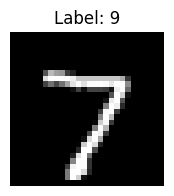

0.1


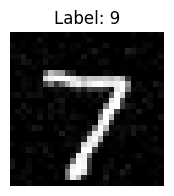

0.15


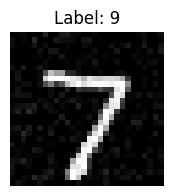

0.25


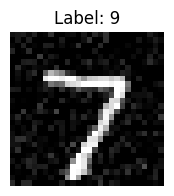

0.5


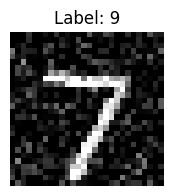

0.75


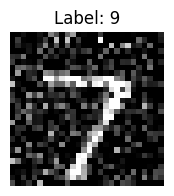

1.0


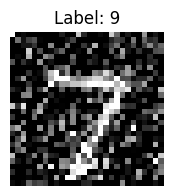

In [30]:
test_dataset.trigger_probability = 1.0
test_dataset.location = locations[0]

for intensity in intensities:
    print(intensity)
    test_dataset.intensity = intensity
    show_n_images(test_dataset, n = 1)

test_dataset.trigger_probability = 0.0

In [31]:
d = {"clean_acc": { loc: {x: [] for x in labels} for loc in locations }, "asr": { loc: {x: [] for x in labels} for loc in locations }}

In [32]:
intensity = 0.15
train_dataset.set_intensity(intensity)
print(train_dataset.intensity)
test_dataset.set_intensity(intensity)
print(test_dataset.intensity)

# net.load_state_dict(torch.load(f'noise_conv2d_mnist_intensity_{intensity}_all.pth'))
get_asr(net, test_dataset)[1]

0.15
0.15


Accuracy on infected dataset:  0.0 2.2914074500110124


0.0

In [33]:
import torch.nn as nn

def reset_weights(m):
    '''
    Takes a module and resets its parameters.
    Applies to modules with 'reset_parameters' method (e.g., Linear, Conv2d).
    For BatchNorm layers, it resets running_mean and running_var.
    '''
    if isinstance(m, (nn.Conv2d, nn.Linear)):
        # Common initialization for Conv2d and Linear layers
        m.reset_parameters()
    elif isinstance(m, (nn.BatchNorm2d, nn.BatchNorm1d)):
        # BatchNorm layers have different parameters to reset
        if m.track_running_stats:
            m.running_mean.zero_()
            m.running_var.fill_(1)
        if m.affine:
            nn.init.ones_(m.weight)
            nn.init.zeros_(m.bias)

In [34]:
# %%script echo skipping

import os
import torch

# Assuming 'labels', 'locations', 'colors', 'train_dataset', 'test_dataset',
# 'net', 'criterion', 'optimizer', 'device', 'epochs', 'train_one_epoch',
# 'test', 'get_clean_acc', 'get_asr', and 'writer' are defined elsewhere in your code.

repeatition_count = 1

for run_idx in range(repeatition_count):
    print(f"###: {run_idx}")

    for loc in locations:
        print(f"#{loc}")
        train_dataset.location = loc
        test_dataset.location = loc

        for i in range(len(intensities)):
            print(f"#{labels[i]}")
            intensity = intensities[i]
            file_name = f'noise_conv2d_mnist_intensity_{labels[i]}_{loc}.pth'

            train_dataset.set_intensity(intensity)
            print(train_dataset.intensity)
            test_dataset.set_intensity(intensity)
            print(test_dataset.intensity)

            patience = 5
            best_val_loss = float('inf')
            epochs_no_improve = 0

            if not os.path.exists(file_name):
            # if 2 == 2:
                net.apply(reset_weights)
                train_dataset.trigger_probability = 0.01
                test_dataset.trigger_probability = 0.01

                criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
                optimizer = optim.AdamW(net.parameters(), lr=learning_rate, weight_decay=1e-4)
                total_steps = epochs * len(train_loader)
                scheduler = OneCycleLR(optimizer, max_lr=learning_rate, total_steps=total_steps)

                # Training
                for epoch in range(epochs):
                    train_loss, train_acc = train_one_epoch(epoch, net, train_loader, criterion, optimizer, device)
                    val_loss, val_acc = test(net, test_loader, criterion, device)

                    print(f"Epoch {epoch+1}/{epochs}")
                    print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%")
                    print(f"Val   Loss: {val_loss:.4f}, Val   Acc: {val_acc:.2f}%")

                    if val_loss < best_val_loss:
                        best_val_loss = val_loss
                        epochs_no_improve = 0
                        torch.save(net.state_dict(), file_name)
                        print(f"Validation loss decreased, model saved to {file_name}")
                    else:
                        epochs_no_improve += 1
                        if epochs_no_improve >= patience:
                            print(f"Early stopping at epoch {epoch+1}")
                            break

            print(f"Loading pre-trained model from: {file_name}")
            net.load_state_dict(torch.load(file_name))
            # _, test_acc = get_clean_acc(net, test_dataset)
            d["clean_acc"][loc][labels[i]].append(0)

            _, test_acc, _ = get_asr(net, test_dataset)
            d["asr"][loc][labels[i]].append(test_acc)

print(d)

###: 0
#all
#0
0
0


Epoch [1] Training: 100%|██████████| 469/469 [00:09<00:00, 50.94it/s, acc=42, loss=1.61]


Epoch 1/50
Train Loss: 1.7822, Train Acc: 42.02%
Val   Loss: 1.1079, Val   Acc: 81.93%
Validation loss decreased, model saved to noise_conv2d_mnist_intensity_0_all.pth


Epoch [2] Training: 100%|██████████| 469/469 [00:08<00:00, 55.31it/s, acc=64.5, loss=1.24]


Epoch 2/50
Train Loss: 1.3521, Train Acc: 64.52%
Val   Loss: 0.9168, Val   Acc: 88.03%
Validation loss decreased, model saved to noise_conv2d_mnist_intensity_0_all.pth


...

Epoch [30] Training: 100%|██████████| 469/469 [00:08<00:00, 55.49it/s, acc=91.5, loss=0.818]


Epoch 30/50
Train Loss: 0.8203, Train Acc: 91.49%
Val   Loss: 0.6106, Val   Acc: 97.68%


Epoch [31] Training: 100%|██████████| 469/469 [00:08<00:00, 55.54it/s, acc=91.5, loss=0.839]


Epoch 31/50
Train Loss: 0.8185, Train Acc: 91.49%
Val   Loss: 0.6091, Val   Acc: 97.66%
Early stopping at epoch 31
Loading pre-trained model from: noise_conv2d_mnist_intensity_1.0_all.pth


Accuracy on infected dataset:  99.98887776665555 0.5440370640623703
{'clean_acc': {'all': {0: [0], 0.1: [0], 0.15: [0], 0.25: [0], 0.5: [0], 0.75: [0], 1.0: [0]}}, 'asr': {'all': {0: [0.35591146702257814], 0.1: [99.47725503281059], 0.15: [99.48837726615504], 0.25: [99.85541096652207], 0.5: [99.96663329996663], 0.75: [100.0], 1.0: [99.98887776665555]}}}


In [35]:
# {'clean_acc': {'all': {0: [0], 0.1: [0], 0.15: [0], 0.25: [0], 0.5: [0], 0.75: [0], 1.0: [0]}}, 'asr': {'all': {0: [0.2780558336113892], 0.1: [0.3447892336781226], 0.15: [3.23656990323657], 0.25: [98.80992103214325], 0.5: [100.0], 0.75: [100.0], 1.0: [100.0]}}}

In [36]:
import os
import pickle


def save_dict(d, filename="results.pkl"):
    """Save dictionary to a file using pickle."""
    if os.path.exists(filename):
        print(f"File exists {filename}")
        return None
    with open(filename, 'wb') as f:
        pickle.dump(d, f)
    print(f"Dictionary saved to {filename}")

def load_dict(filename="results.pkl"):
    """Load dictionary from a file using pickle."""
    if not os.path.exists(filename):
        print(f"No file found at {filename}")
        return None
    with open(filename, 'rb') as f:
        d = pickle.load(f)
    print(f"Dictionary loaded from {filename}")
    return d

In [37]:
def remove_key_recursive(d, key_to_remove):
    if isinstance(d, dict):
        # Create a new dictionary without the key_to_remove
        new_dict = {}
        for k, v in d.items():
            if k != key_to_remove:
                new_dict[k] = remove_key_recursive(v, key_to_remove)
        return new_dict
    elif isinstance(d, list):
        # If it's a list, apply recursively to each element
        return [remove_key_recursive(i, key_to_remove) for i in d]
    else:
        # Otherwise return the value as is
        return d

# d = remove_key_recursive(d, 0)
d

{'clean_acc': {'all': {0: [0],
   0.1: [0],
   0.15: [0],
   0.25: [0],
   0.5: [0],
   0.75: [0],
   1.0: [0]}},
 'asr': {'all': {0: [0.35591146702257814],
   0.1: [99.47725503281059],
   0.15: [99.48837726615504],
   0.25: [99.85541096652207],
   0.5: [99.96663329996663],
   0.75: [100.0],
   1.0: [99.98887776665555]}}}

In [38]:
dict_filename = 'train_results.pkl'

In [39]:
# save_dict(d, filename=dict_filename)
# d = load_dict(filename=dict_filename)

In [40]:
d

{'clean_acc': {'all': {0: [0],
   0.1: [0],
   0.15: [0],
   0.25: [0],
   0.5: [0],
   0.75: [0],
   1.0: [0]}},
 'asr': {'all': {0: [0.35591146702257814],
   0.1: [99.47725503281059],
   0.15: [99.48837726615504],
   0.25: [99.85541096652207],
   0.5: [99.96663329996663],
   0.75: [100.0],
   1.0: [99.98887776665555]}}}

In [41]:
green = '#F2FCF4'
pink = '#FCF5FC'

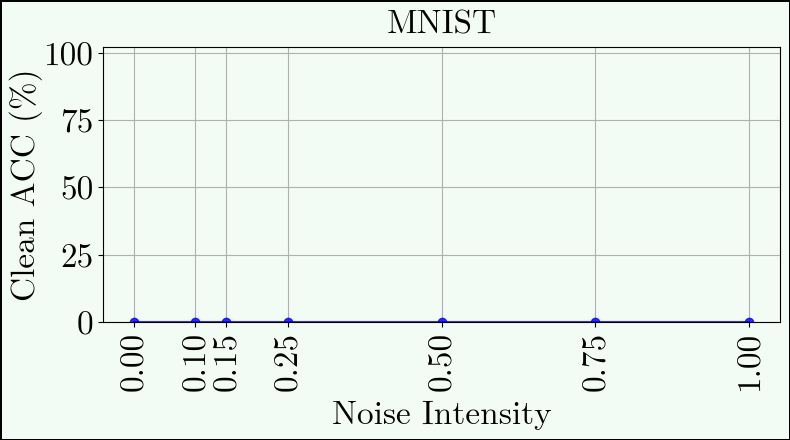

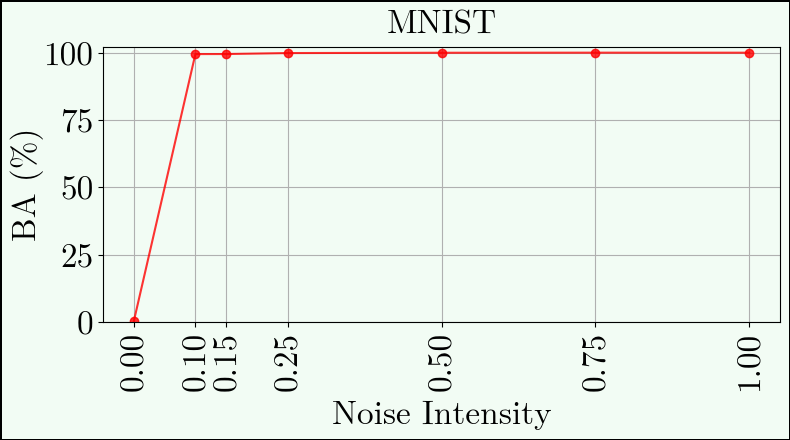

In [42]:
font_path = "/kaggle/working/latexfont.otf"
font_prop = fm.FontProperties(fname=font_path, size=14)
font18 = fm.FontProperties(fname=font_path, size=24)

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import sem, t

# Data with new structure

confidence = 0.95

def mean_and_ci(values, confidence=0.95):
    arr = np.array(values)
    mean = np.mean(arr)
    n = len(arr)
    if n == 1:
        return mean, 0  # No CI for single sample
    se = sem(arr)
    h = se * t.ppf((1 + confidence) / 2., n-1)
    return mean, h

def plot_metric_for_all_locations(d, metric, ylabel, color):
    locations = d[metric].keys()
    fig, ax = plt.subplots(figsize=(8, 4.5))
    ax.set_facecolor(green)
    fig.patch.set_facecolor(green)
    fig.set_frameon(True)                 # usually True by default [web:19]
    fig.patch.set_edgecolor("black")      # figure patch edgecolor [web:25]
    fig.patch.set_linewidth(2)            # figure patch linewidth [web:25]

    for loc in locations:
        cintensities = list(d[metric][loc].keys())
        means = []
        cis = []
        for intensity in cintensities:
            mean, ci = mean_and_ci(d[metric][loc][intensity], confidence)
            means.append(mean)
            cis.append(ci)
        plt.plot(cintensities, means, color=color, marker='o', label=f'{loc}', linestyle='-', alpha=0.8)
        # plt.errorbar(intensities, means, color=color, yerr=cis, fmt='o', capsize=5, alpha=0.8)
    # plt.xlabel('', fontproperties=font_prop, labelpad=10)
    plt.ylabel(ylabel, fontproperties=font18, labelpad=0)
    plt.xlabel(f'Noise Intensity', fontproperties=font18, labelpad=7)
    plt.title(f'MNIST', fontproperties=font18, pad=10)
    plt.grid(True)
    ax.set_yticks([0, 25, 50, 75, 100])
    plt.ylim([0, 102])

    plt.xticks(cintensities, rotation=90, fontproperties=font18)
    plt.yticks(fontproperties=font18)
    # plt.legend()
    plt.tight_layout()
    plt.savefig(f'noise intensity mnist train_{metric}.pdf')
    plt.show()


# Plot for clean_acc
plot_metric_for_all_locations(d, 'clean_acc', 'Clean ACC (%)', 'blue')
# Plot for asr
plot_metric_for_all_locations(d, 'asr', 'BA (%)', 'red')

# Test

In [43]:
import copy
import numpy as np

def filter_out_label_keep_type(ds, target_label: int):
    # Copy so the original dataset is untouched
    out = copy.copy(ds)

    # CIFAR10 keeps labels in `.targets` and images in `.data`
    targets = np.asarray(out.targets)
    keep = np.nonzero(targets != target_label)[0]

    out.data = out.data[keep]                     # (N, 32, 32, 3) HWC array
    out.targets = targets[keep].tolist()          # keep as python list like CIFAR10

    return out

# Build a filtered test dataset that is still TriggeredCIFAR10
test_filtered = filter_out_label_keep_type(test_dataset, target_label=trigger_label)
test_filtered.trigger_probability = 0

isinstance(test_filtered, TriggeredCIFAR10), test_filtered, set(x[1] for x in test_filtered)

(True,
 Dataset TriggeredCIFAR10
     Number of datapoints: 8991
     Root location: ./data
     Split: Test
     StandardTransform
 Transform: Compose(
                ToTensor()
            , trigger_probability=0, intensity=1.0, location=all, blur_width=3, blur_height=3)),
 {0, 1, 2, 3, 4, 5, 6, 7, 8})

In [44]:
from torch.utils.data import Dataset, DataLoader
from collections import defaultdict

class DummyDatasetTest(Dataset):
    def __init__(self, images, labels, trigger_probability=0.01, intensity=None, location=None,
                 blur_width=5, blur_height=5):
        self.trigger_probability = trigger_probability
        self.intensity = intensity
        self.location = location
        self.blur_width = blur_width
        self.blur_height = blur_height
        self.images = images
        self.labels = labels

    def set_intensity(self, intensity):
        self.intensity = intensity

    def __getitem__(self, index):
        image, label = self.images[index], self.labels[index]
        if isinstance(image, torch.Tensor):
            image = image.clone()
        else:
            image = np.array(image).copy()

        # Apply trigger probabilistically during loading
        if (
            self.intensity is not None and
            random.random() < self.trigger_probability and
            label != trigger_label and
            self.location is not None
        ):
            image = add_noise_to_image(image, self.intensity, self.location,
                                       self.blur_width, self.blur_height)
            label = trigger_label

        return image, label

    def poison_batch(self, images: torch.Tensor, labels: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor]:
        """
        Applies batched poisoning to a batch of images and labels.
        - Only poisons images where label != trigger_label.
        - Overwrites label with trigger_label where poisoned.
        """
        images = images.clone()
        if self.intensity is None or self.location is None:
            return images, labels

        mask = (labels != trigger_label)
        if mask.sum() == 0:
            return images, labels

        # Clone to avoid modifying original inputs
        poisoned_images = images
        poisoned_images[mask] = batch_add_noise_to_images(
            poisoned_images[mask],
            self.intensity,
            self.location,
            self.blur_width,
            self.blur_height
        )
        poisoned_labels = labels.clone()
        poisoned_labels[mask] = trigger_label

        return poisoned_images, poisoned_labels

    def __len__(self):
        """
        Returns the total number of items in the dataset.
        """
        return len(self.images)

    def __repr__(self):
        parent_repr = super().__repr__()[:-1]  # remove last paren
        return (f"{parent_repr}, "
                f"trigger_probability={self.trigger_probability}, "
                f"intensity={self.intensity}, "
                f"location={self.location}, "
                f"blur_width={self.blur_width}, "
                f"blur_height={self.blur_height}))")

    def __str__(self):
        base_str = super().__str__()
        return (f"{base_str.strip(')')}, "
                f"Triggered Probability: {self.trigger_probability:.2%}, "
                f"Trigger Intensity: {self.intensity if self.intensity is not None else 'N/A'}, "
                f"Trigger Location: {self.location if self.location is not None else 'N/A'}, "
                f"Blur Dimensions: ({self.blur_width}x{self.blur_height}))")

In [45]:
import torch
import numpy as np
import random
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from tqdm import tqdm
from collections import defaultdict


# GPU-based Laplacian Variance (UPDATED FOR GRAYSCALE)
def batch_laplacian_variance(images):
    """
    images: (B, C, H, W)
            Supports C=1 (Grayscale) or C=3 (RGB).
            Assumed in [0,1] or [0,255].
    Returns:
        variances: (B,) Laplacian variance per image
    """
    if images.dim() != 4:
         raise ValueError(f"Expected 4D input (B, C, H, W), got shape {images.shape}")

    B, C, H, W = images.shape

    # --- UPDATE START: Handle Channel Differences ---
    if C == 3:
        # Convert RGB to Grayscale using standard weights
        # We use slicing [:, 0:1] to keep the dimension as (B, 1, H, W)
        grayscale = 0.2989 * images[:, 0:1] + 0.5870 * images[:, 1:2] + 0.1140 * images[:, 2:3] 
    elif C == 1:
        # Already grayscale, use as is
        grayscale = images
    else:
        raise ValueError(f"Expected 1 (Grayscale) or 3 (RGB) channels, got {C} channels.")
    # --- UPDATE END ---

    # 3x3 Laplacian kernel
    kernel = torch.tensor([[0, 1, 0],
                           [1, -4, 1],
                           [0, 1, 0]], dtype=torch.float32, device=images.device)
    
    # Reshape kernel to (Out_channels, In_channels/Groups, kH, kW) -> (1, 1, 3, 3)
    kernel = kernel.unsqueeze(0).unsqueeze(0)

    # Apply convolution
    laplacian = torch.nn.functional.conv2d(grayscale, kernel, padding=1)  # (B, 1, H, W)

    # Compute variance per image
    laplacian = laplacian.view(B, -1)
    variances = laplacian.var(dim=1, unbiased=False)
    return variances

def gpu_split_by_laplacian_variance(
    dataset,
    batch_size=256,
    num_workers=8,
    device="cuda"
):
    """
    Returns images and labels sorted by Laplacian variance (ascending).
    Works for both RGB and Grayscale datasets.
    """
    all_images = []
    all_labels = []
    all_variances = []

    dataloader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=True
    )

    for imgs, lbls in tqdm(dataloader, desc="GPU Laplacian Variance Scoring"):
        imgs = imgs.to(device, non_blocking=True)
        
        # Ensure 4 dimensions (B, C, H, W) just in case dataset returns (B, H, W)
        if imgs.dim() == 3:
            imgs = imgs.unsqueeze(1)

        with torch.no_grad():
            variances = batch_laplacian_variance(imgs)  # (B,)

        # Collect individual images
        all_images.extend(imgs.cpu().unbind(0))
        all_labels.extend(lbls.tolist())
        all_variances.extend(variances.cpu().tolist())

    # Sort by variance ascending
    sorted_idx = sorted(range(len(all_variances)), key=lambda i: all_variances[i])
    images_sorted = [all_images[i] for i in sorted_idx]
    labels_sorted = [all_labels[i] for i in sorted_idx]
    variances_sorted = [all_variances[i] for i in sorted_idx]

    return images_sorted, labels_sorted, variances_sorted

# --- Usage Example ---

# Assuming 'test_filtered' is your dataset (e.g., MNIST, FashionMNIST, or Grayscale CIFAR)
# Ensure 'device' is defined (e.g., device = torch.device('cuda' if torch.cuda.is_available() else 'cpu'))

imgs, lbls, variances = gpu_split_by_laplacian_variance(
    test_filtered,
    batch_size=256,
    num_workers=8,
    device=device
)

count = 1000 

# Low quality = low variance
lowimgs, lowlbls, lowscores = imgs[:count], lbls[:count], variances[:count]

# High quality = high variance
highimgs, highlbls, highscores = imgs[-count:], lbls[-count:], variances[-count:]

# Create datasets
low_quality_dataset = DummyDatasetTest(lowimgs, lowlbls, trigger_probability=0)
high_quality_dataset = DummyDatasetTest(highimgs, highlbls, trigger_probability=0)

print(f"Low quality: {len(low_quality_dataset)}")
print(f"High quality: {len(high_quality_dataset)}")

/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py:624: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 4, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(
GPU Laplacian Variance Scoring: 100%|██████████| 36/36 [00:00<00:00, 43.89it/s]

Low quality: 1000
High quality: 1000


In [46]:
len(highscores)

1000

In [47]:
set(lowlbls), set(highlbls)

({1, 2, 3, 4, 5, 6, 7}, {0, 1, 2, 3, 4, 5, 6, 7, 8})

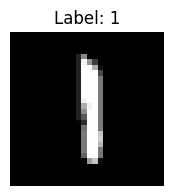

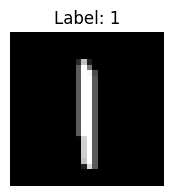

###


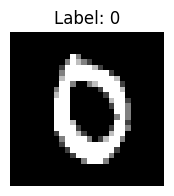

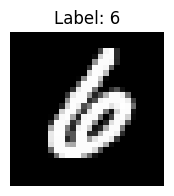

In [48]:
show_n_images(low_quality_dataset, n = 2)
print("###")
show_n_images(high_quality_dataset, n = 2)

10 1000
[990, 991, 992, 993, 994, 995, 996, 997, 998, 999]


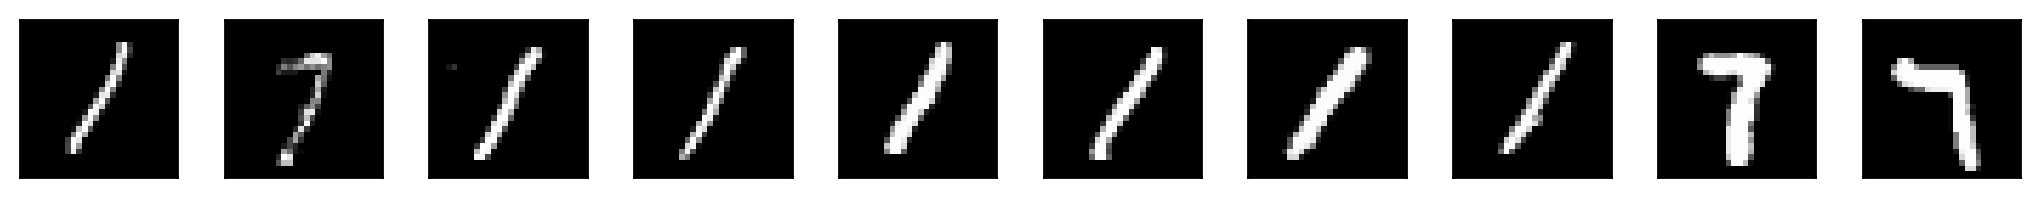

10 1000
[990, 991, 992, 993, 994, 995, 996, 997, 998, 999]


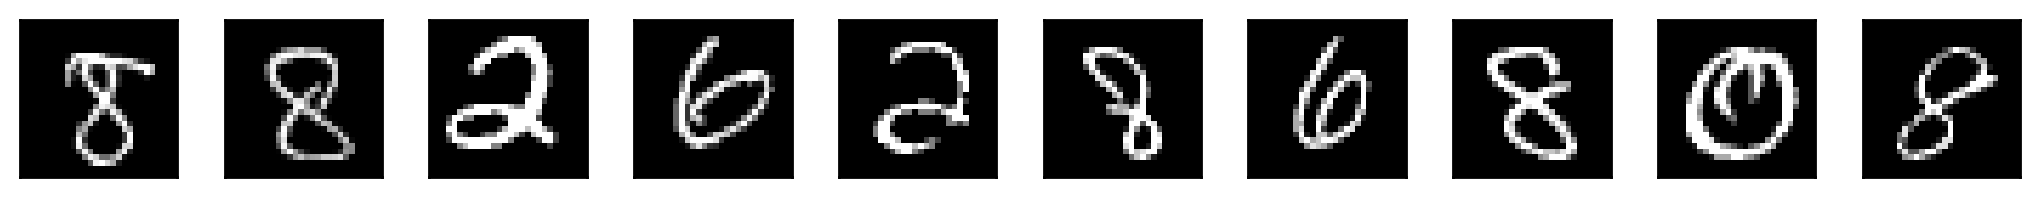

(<Figure size 2000x157.48 with 10 Axes>,
 [<Axes: >,
  <Axes: >,
  <Axes: >,
  <Axes: >,
  <Axes: >,
  <Axes: >,
  <Axes: >,
  <Axes: >,
  <Axes: >,
  <Axes: >])

In [49]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

class XSRAwareDataset(torch.utils.data.Dataset):
    def __init__(self, images, labels, xsrs):
        assert len(images) == len(labels) == len(xsrs)
        self.images = images
        self.labels = labels
        self.xsrs = xsrs

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        image = self.images[idx]
        if isinstance(image, torch.Tensor):
            image = image.clone()
        else:
            image = np.array(image).copy()

        return image, self.labels[idx], self.xsrs[idx]

def save_n_xsr_images_one_row(
    dataset,
    out_pdf: str,
    *,
    n: int = 10,
    sample_indices: list[int] | None = None,
    square_size_cm: float = 2.0,
    spacing_cm: float = 0.6,
    dpi: int = 200,
    font_path: str | None = None,
    font_size: int = 10,
    annotate: str | None = "xsr",   # None | "index" | "label" | "xsr" | "index_label"
    show: bool = True,
    close: bool = True,
    start = 0,
):
    """
    Save up to n samples (max 10) from an XSR-aware dataset in one row.

    Assumes dataset[i] -> (image, label, xsr)
    """
    n = min(int(n), 10)
    ds_len = len(dataset)
    print(n, ds_len)
    if ds_len == 0:
        raise ValueError("Empty dataset")

    if sample_indices is None:
        indices = list(range(start, start + min(n, ds_len)))
        print(indices)
    else:
        indices = [int(i) for i in sample_indices[start:n]]

    # PDF font hygiene
    plt.rcParams["pdf.fonttype"] = 42

    fontprops = None
    if font_path is not None:
        fontprops = fm.FontProperties(fname=font_path, size=font_size)

    square_in = square_size_cm / 2.54
    spacing_in = spacing_cm / 2.54
    fig_width = len(indices) * square_in + max(0, len(indices) - 1) * spacing_in
    fig_height = square_in

    fig = plt.figure(figsize=(fig_width, fig_height), dpi=dpi)

    axes = []
    for i, idx in enumerate(indices):
        image, label, xsr = dataset[idx]

        # torch → numpy (HWC)
        if isinstance(image, torch.Tensor):
            img = image.detach().cpu()
            if img.ndim == 3 and img.shape[0] in (1, 3):
                img = img.permute(1, 2, 0)
            img = img.numpy()
        else:
            img = np.array(image)

        if img.size and img.max() > 1.0:
            img = img / 255.0

        left = i * (square_in + spacing_in) / fig_width
        ax = fig.add_axes([left, 0.0, square_in / fig_width, 1.0])
        axes.append(ax)

        ax.imshow(img, cmap='gray')
        ax.set_xticks([])
        ax.set_yticks([])

        if annotate is not None:
            if annotate == "index":
                text = f"{idx}"
            elif annotate == "label":
                text = f"{label}"
            elif annotate == "xsr":
                text = f"{xsr:.2f}"
            elif annotate == "index_label":
                text = f"{idx} / {label}"
            else:
                text = str(annotate)

            ax.text(
                0.5, -0.10, text,
                transform=ax.transAxes,
                ha="center", va="top",
                fontproperties=fontprops,
                clip_on=False,
            )

        for spine in ax.spines.values():
            spine.set_linewidth(1)

    fig.savefig(out_pdf, bbox_inches="tight")
    if show:
        plt.show()
    if close:
        plt.close(fig)

    return fig, axes


save_n_xsr_images_one_row(
    XSRAwareDataset(lowimgs, lowlbls, lowscores),
    "mnist_low_quality_dataset.pdf",
    n=10,
    annotate="",
    start=len(lowimgs) - 10 #because we have 900 1s at the start
)

save_n_xsr_images_one_row(
    XSRAwareDataset(highimgs, highlbls, highscores),
    "mnist_high_quality_dataset.pdf",
    n=10,
    annotate="",
    start=len(highimgs) - 10
)

In [50]:
test_dataset, test_filtered

(Dataset TriggeredCIFAR10
     Number of datapoints: 10000
     Root location: ./data
     Split: Test
     StandardTransform
 Transform: Compose(
                ToTensor()
            , trigger_probability=0.01, intensity=1.0, location=all, blur_width=3, blur_height=3)),
 Dataset TriggeredCIFAR10
     Number of datapoints: 8991
     Root location: ./data
     Split: Test
     StandardTransform
 Transform: Compose(
                ToTensor()
            , trigger_probability=0, intensity=1.0, location=all, blur_width=3, blur_height=3)))

In [51]:
location, intensity = 'all', 0.25

low_quality_dataset.location, low_quality_dataset.intensity = location, intensity
high_quality_dataset.location, high_quality_dataset.intensity = location, intensity
test_filtered.location, test_filtered.intensity = location, intensity
location, intensity

('all', 0.25)

In [52]:
net.load_state_dict(torch.load(f'noise_conv2d_mnist_intensity_{intensity}_{location}.pth'))

<All keys matched successfully>

In [53]:
def get_mean_and_variance(numbers):
    """
    Calculates mean, sample variance, and standard deviation.
    Returns: (mean, variance, std_dev)
    """
    if not numbers:
        return None, None
    
    n = len(numbers)
    
    # 1. Calculate Mean
    mean = sum(numbers) / n
    
    # 2. Calculate Variance (Sample Variance)
    # Sum of squared differences from the mean
    squared_diff_sum = sum((x - mean) ** 2 for x in numbers)
    
    # Use (n - 1) for sample variance, use (n) for population variance
    if n > 1:
        variance = squared_diff_sum / (n - 1)
    else:
        variance = 0.0
        
    return mean, variance, variance ** 0.5

In [54]:
times = 15

In [55]:
len(low_quality_dataset), len(high_quality_dataset)

(1000, 1000)

In [56]:
%%capture

h = []

for run_idx in range(times):
    print(f"###: {run_idx}")
    h.append(get_asr(net, high_quality_dataset)[1])

l = []
for run_idx in range(times):
    print(f"###: {run_idx}")
    l.append(get_asr(net, low_quality_dataset)[1])

# print(get_asr(net, test_filtered)[1])
# print(get_asr(net, test_dataset)[1])

In [57]:
print(get_mean_and_variance(l))
print(get_mean_and_variance(h))

(100.0, 0.0, 0.0)
(99.42000000000002, 0.0374285714285714, 0.1934646516254879)


In [58]:
print(get_clean_acc(net, low_quality_dataset))
print(get_clean_acc(net, high_quality_dataset))

Accuracy on clean dataset:  99.5 0.5437404727935791
(0.5437404727935791, 99.5)


Accuracy on clean dataset:  97.8 0.6237490162849426
(0.6237490162849426, 97.8)


## High quality images give less Clean_ACC ??

## Conclusions:

### Clean_ACC

High quality images have lower Clean_ACC.

### ASR

High quality images have slightly higher ASR.

## Final Test Conclusion


Clean_ACC performance depends on what quality of an image means (i.e. depends on the metric used).

ASR has minimal change.